In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

df.info()

Shape: (200, 5)
Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df = df.rename(columns={
    "Annual Income (k$)": "Income",
    "Spending Score (1-100)": "SpendingScore"
})

df.head()

,CustomerID,Gender,Age,Income,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
df.describe()

,CustomerID,Age,Income,SpendingScore
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
df["Gender"].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

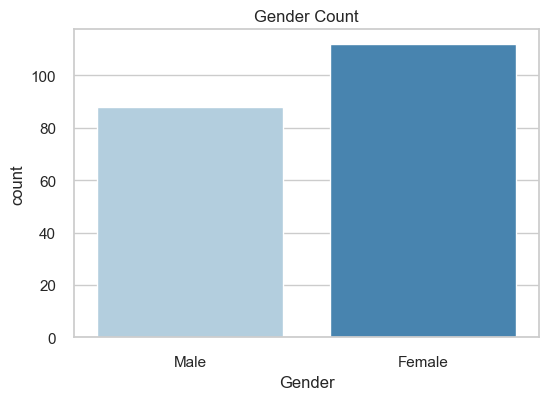

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Gender", hue="Gender", palette="Blues", legend=False)
plt.title("Gender Count")
plt.show()

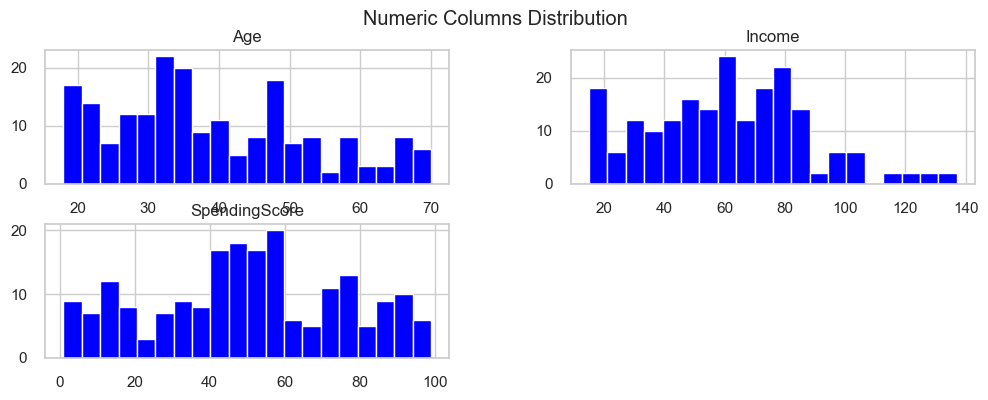

In [11]:
numeric_cols = ["Age", "Income", "SpendingScore"]

df[numeric_cols].hist(figsize=(12, 4), bins=20, color="blue", edgecolor="white")
plt.suptitle("Numeric Columns Distribution")
plt.show()

In [12]:
gender_mean = df.groupby("Gender")[["Age", "Income", "SpendingScore"]].mean()
gender_mean

,Age,Income,SpendingScore
Gender,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


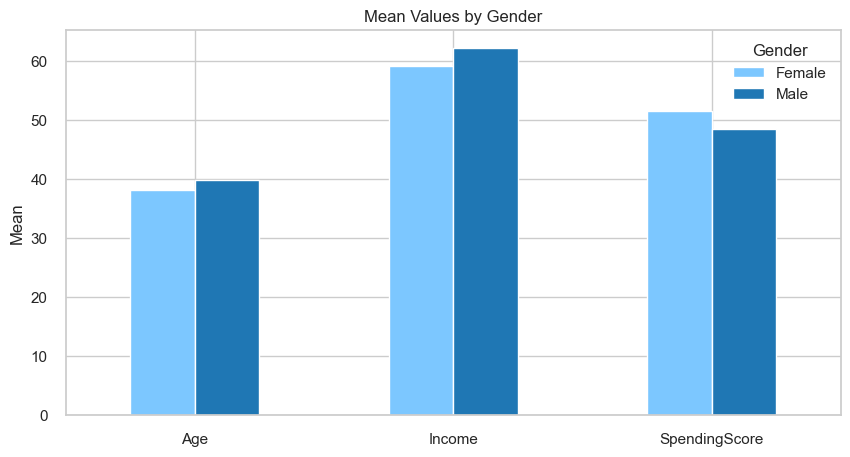

In [13]:
gender_mean.T.plot(kind="bar", figsize=(10, 5), color=["#7cc7ff", "#1f77b4"])
plt.title("Mean Values by Gender")
plt.ylabel("Mean")
plt.xticks(rotation=0)
plt.show()

In [14]:
df["Gender_ID"] = df["Gender"].map({"Female": 0, "Male": 1})
df[["Gender", "Gender_ID", "Age", "Income", "SpendingScore"]].head()

,Gender,Gender_ID,Age,Income,SpendingScore
0,Male,1,19,15,39
1,Male,1,21,15,81
2,Female,0,20,16,6
3,Female,0,23,16,77
4,Female,0,31,17,40


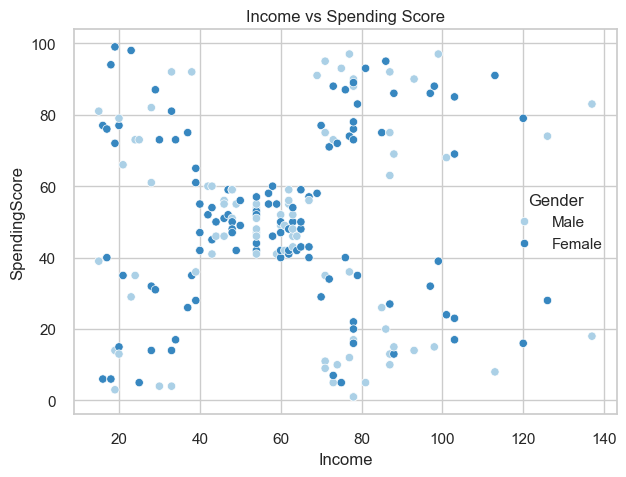

In [15]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Income", y="SpendingScore", hue="Gender", palette="Blues")
plt.title("Income vs Spending Score")
plt.show()

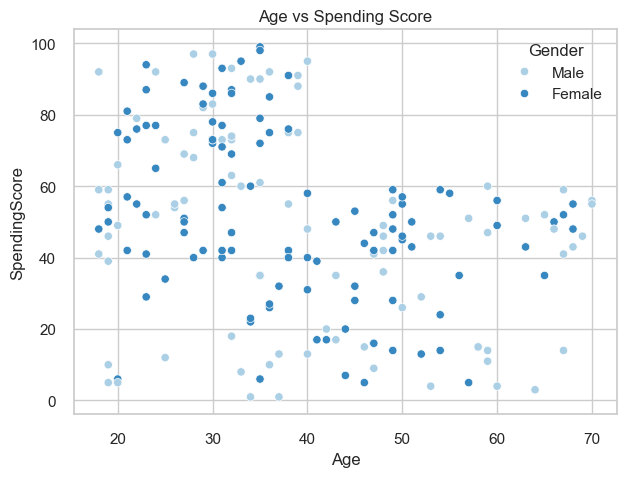

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Age", y="SpendingScore", hue="Gender", palette="Blues")
plt.title("Age vs Spending Score")
plt.show()

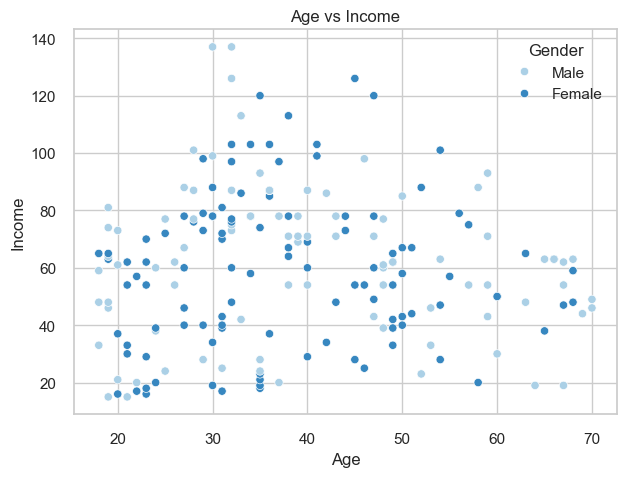

In [17]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Age", y="Income", hue="Gender", palette="Blues")
plt.title("Age vs Income")
plt.show()

In [18]:
analysis_df = df[["Gender_ID", "Age", "Income", "SpendingScore"]]
cov_matrix = analysis_df.cov()
cov_matrix

,Gender_ID,Age,Income,SpendingScore
Gender_ID,0.247638,0.423116,0.737286,-0.746734
Age,0.423116,195.133166,-4.548744,-118.040201
Income,0.737286,-4.548744,689.835578,6.716583
SpendingScore,-0.746734,-118.040201,6.716583,666.854271


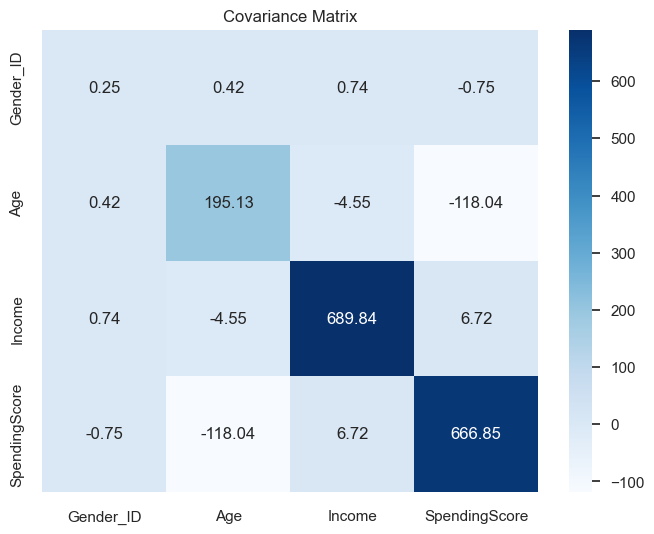

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Covariance Matrix")
plt.show()

In [20]:
pairs = []
cols = analysis_df.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append({
            "Feature 1": cols[i],
            "Feature 2": cols[j],
            "Covariance": cov_matrix.loc[cols[i], cols[j]]
        })

cov_pairs = pd.DataFrame(pairs).sort_values("Covariance", ascending=False)
cov_pairs

,Feature 1,Feature 2,Covariance
5,Income,SpendingScore,6.716583
1,Gender_ID,Income,0.737286
0,Gender_ID,Age,0.423116
2,Gender_ID,SpendingScore,-0.746734
3,Age,Income,-4.548744
4,Age,SpendingScore,-118.040201


In [21]:
for _, row in cov_pairs.iterrows():
    cov_value = row["Covariance"]
    f1 = row["Feature 1"]
    f2 = row["Feature 2"]
    
    if cov_value > 0:
        direction = "مثبت"
    elif cov_value < 0:
        direction = "منفی"
    else:
        direction = "صفر"
    
    print(f"{f1} و {f2}: covariance = {cov_value:.2f} -> رابطه کلی {direction}")

Income و SpendingScore: covariance = 6.72 -> رابطه کلی مثبت
Gender_ID و Income: covariance = 0.74 -> رابطه کلی مثبت
Gender_ID و Age: covariance = 0.42 -> رابطه کلی مثبت
Gender_ID و SpendingScore: covariance = -0.75 -> رابطه کلی منفی
Age و Income: covariance = -4.55 -> رابطه کلی منفی
Age و SpendingScore: covariance = -118.04 -> رابطه کلی منفی


In [22]:
corr_matrix = analysis_df.corr()
corr_matrix

,Gender_ID,Age,Income,SpendingScore
Gender_ID,1.000000,0.060867,0.056410,-0.058109
Age,0.060867,1.000000,-0.012398,-0.327227
Income,0.056410,-0.012398,1.000000,0.009903
SpendingScore,-0.058109,-0.327227,0.009903,1.000000


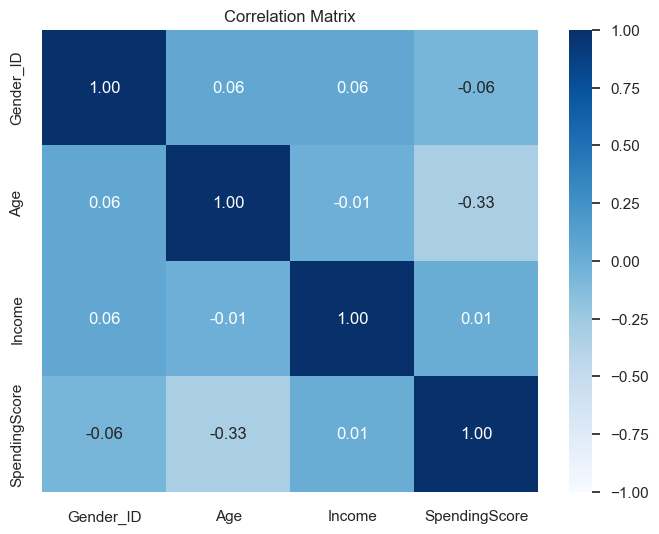

In [23]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()